# APE 003 - Variables Aleatorias Discretas y Continuas

**Estudiantes:** Willan Granda, Darwin Campoverde, Axel Jiménez, Bayron Coronel, Jeancarlos Aguirre.

**Asignatura:** Teoría de la Distribución y Probabilidad  
**Carrera:** Computación  
**Ciclo:** 2do "A"  
**Docente:** Cristian Ramiro Narváez Guillén  
**Fecha:** Martes 28 de abril 2026  

**Objetivos de la Práctica:**
1. Diferenciar con precisión formal entre variables aleatorias discretas y continuas
2. Interpretar y construir funciones de masa de probabilidad (PMF) y funciones de densidad de probabilidad (PDF) utilizando Python
3. Calcular probabilidades acumuladas mediante el uso de la función de distribución acumulada (CDF)

**Metodología Activa:** Enfoque PID-2025: ABP (Aprendizaje Basado en Problemas) y ABI

In [4]:
# =====================================================================
# TAREA 1: CONFIGURACIÓN DEL ENTORNO DE TRABAJO
# =====================================================================
# Importación de las librerías científicas y de visualización requeridas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, norm, binom, uniform

# Configuración del estilo visual siguiendo el estándar institucional
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

print("✅ Entorno configurado correctamente.")
print(f"NumPy versión: {np.__version__}")
print(f"Pandas versión: {pd.__version__}")

✅ Entorno configurado correctamente.
NumPy versión: 2.0.2
Pandas versión: 2.2.2


## Tarea 2: Variable Aleatoria Discreta - Lanzamiento de un Dado Justo

**Caso de estudio:** Sea $X$ el resultado numérico obtenido al lanzar un dado legal de 6 caras.
* El espacio muestral es $\Omega = \{1, 2, 3, 4, 5, 6\}$[cite: 80].
* Dado que el dado es justo, la probabilidad de cada cara es uniforme e igual a $p(x) = \frac{1}{6}$.

Propiedades de una PMF evaluadas:
1. $0 \le p(x) \le 1$ para todo $x$.
2. $\sum p(x_i) = 1$.

In [5]:
x_valores = np.array([1, 2, 3, 4, 5, 6])
pmf_dado = np.full(6, 1/6)
cdf_dado = np.cumsum(pmf_dado)

print("Valores de X (resultado del dado):", x_valores)
print("PMF (probabilidad de cada resultado):", np.round(pmf_dado, 4))
print("CDF (probabilidad acumulada):", np.round(cdf_dado, 4))

Valores de X (resultado del dado): [1 2 3 4 5 6]
PMF (probabilidad de cada resultado): [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
CDF (probabilidad acumulada): [0.1667 0.3333 0.5    0.6667 0.8333 1.    ]


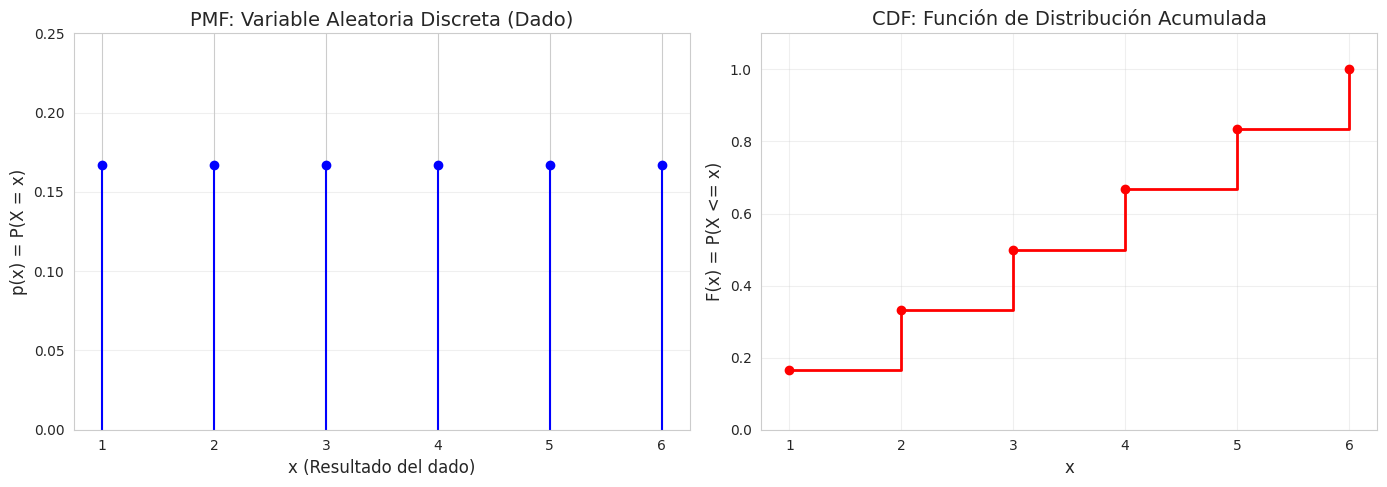

In [6]:
# =====================================================================
# VISUALIZACIÓN GRÁFICA DE PMF Y CDF (DADO)
# =====================================================================

plt.figure(figsize=(14, 5))

# Subplot izquierdo: Función de Masa de Probabilidad (PMF)
plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# Subplot derecho: Función de Distribución Acumulada (CDF)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2, label='F(x) acumulada')
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Función de Distribución Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# =====================================================================
# CÁLCULO DE PROBABILIDADES ESPECÍFICAS SOLICITADAS
# =====================================================================

# a) P(X = 4) obtenido directamente de la PMF
prob_4 = pmf_dado[x_valores == 4][0]

# b) P(X <= 3) obtenido indexando la CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]

# c) P(2 <= X <= 5) calculado algebraicamente como F(5) - F(1)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]

print("RESULTADOS DE EVALUACIÓN DISCRETA:")
print("=" * 50)
print(f"a) P(X = 4)                = {prob_4:.4f}")
print(f"b) P(X <= 3)               = {prob_menor_3:.4f}")
print(f"c) P(2 <= X <= 5) [F(5)-F(1)] = {prob_entre_2_5:.4f}")
print("=" * 50)

RESULTADOS DE EVALUACIÓN DISCRETA:
a) P(X = 4)                = 0.1667
b) P(X <= 3)               = 0.5000
c) P(2 <= X <= 5) [F(5)-F(1)] = 0.6667


## Tarea 3: Variable Aleatoria Continua - Tiempos de Respuesta del Servidor
**Caso de estudio:** Sea $X$ el tiempo de respuesta de un servidor de la UNL medido en milisegundos (ms).
Este tiempo se modela mediante una distribución normal con media $\mu = 200 \text{ ms}$ y desviación estándar $\sigma = 30 \text{ ms}$.

$$X \sim \mathcal{N}(\mu = 200, \sigma^2 = 30^2)$$

Propiedades de una PDF evaluadas:
1. $f(x) \ge 0$ para todo $x$.
2. $\int_{-\infty}^{+\infty} f(x)dx = 1$.
3. $P(X = x) = 0$ para cualquier valor puntual específico de $x$.

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_14739/484068408.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x_linea, pdf_normal, 'b-', linewidth=2, label=f'$\mathcal{{N}}({mu}, {sigma}^2)$')


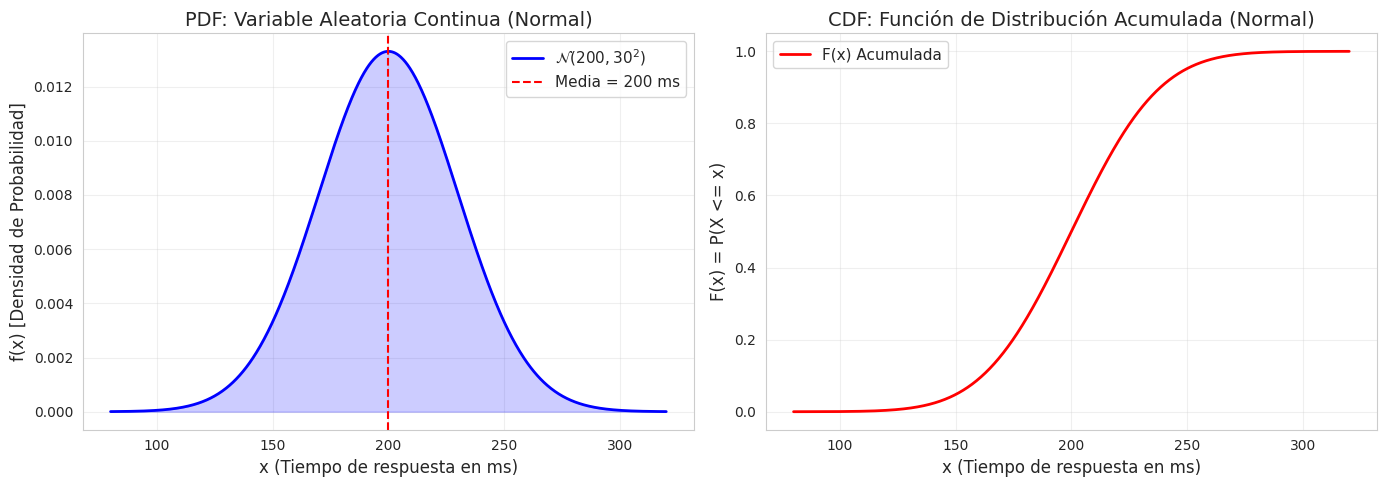

In [8]:
# =====================================================================
# TAREA 3: VARIABLE ALEATORIA CONTINUA (DISTRIBUCIÓN NORMAL)
# =====================================================================

# 1. Parámetros de la distribución normal
mu = 200      # Media (ms)
sigma = 30    # Desviación estándar (ms)

# 2. Creación del objeto de distribución continua usando SciPy
dist_normal = norm(loc=mu, scale=sigma)

# 3. Rango de valores simétricos para el eje X (4 desviaciones estándar)
x_linea = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# 4. Cálculo de las funciones de densidad (PDF) y acumulada (CDF)
pdf_normal = dist_normal.pdf(x_linea)
cdf_normal = dist_normal.cdf(x_linea)

# --- Construcción Gráfica de PDF y CDF ---
plt.figure(figsize=(14, 5))

# Subplot izquierdo: PDF
plt.subplot(1, 2, 1)
plt.plot(x_linea, pdf_normal, 'b-', linewidth=2, label=f'$\mathcal{{N}}({mu}, {sigma}^2)$')
plt.fill_between(x_linea, pdf_normal, color='blue', alpha=0.2)
plt.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Media = {mu} ms')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x) [Densidad de Probabilidad]')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# Subplot derecho: CDF
plt.subplot(1, 2, 2)
plt.plot(x_linea, cdf_normal, 'r-', linewidth=2, label='F(x) Acumulada')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Función de Distribución Acumulada (Normal)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# =====================================================================
# EVALUACIÓN DE PROBABILIDADES CONTINUAS E INFERENCIA DE EXTREMOS
# =====================================================================

# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)

# b) P(X > 250) = 1 - F(250)
prob_mayor_250 = 1 - dist_normal.cdf(250)

# c) P(170 <= X <= 230) = F(230) - F(170)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)

# d) Percentil 95 (Función Inversa de la CDF - PPF)
p95 = dist_normal.ppf(0.95)

print("ANÁLISIS DE TIEMPOS DE RESPUESTA EN SERVIDORES:")
print("=" * 65)
print(f"a) P(X <= 180)          = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")
print(f"b) P(X > 250)           = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")
print(f"c) P(170 <= X <= 230)   = {prob_entre:.4f} ({prob_entre*100:.2f}%)")
print("-" * 65)
print(f"d) Percentil 95         = {p95:.2f} ms")
print(f"INTERPRETACIÓN: El 95% de los accesos al servidor toman menos de {p95:.2f} ms.")
print("=" * 65)

ANÁLISIS DE TIEMPOS DE RESPUESTA EN SERVIDORES:
a) P(X <= 180)          = 0.2525 (25.25%)
b) P(X > 250)           = 0.0478 (4.78%)
c) P(170 <= X <= 230)   = 0.6827 (68.27%)
-----------------------------------------------------------------
d) Percentil 95         = 249.35 ms
INTERPRETACIÓN: El 95% de los accesos al servidor toman menos de 249.35 ms.


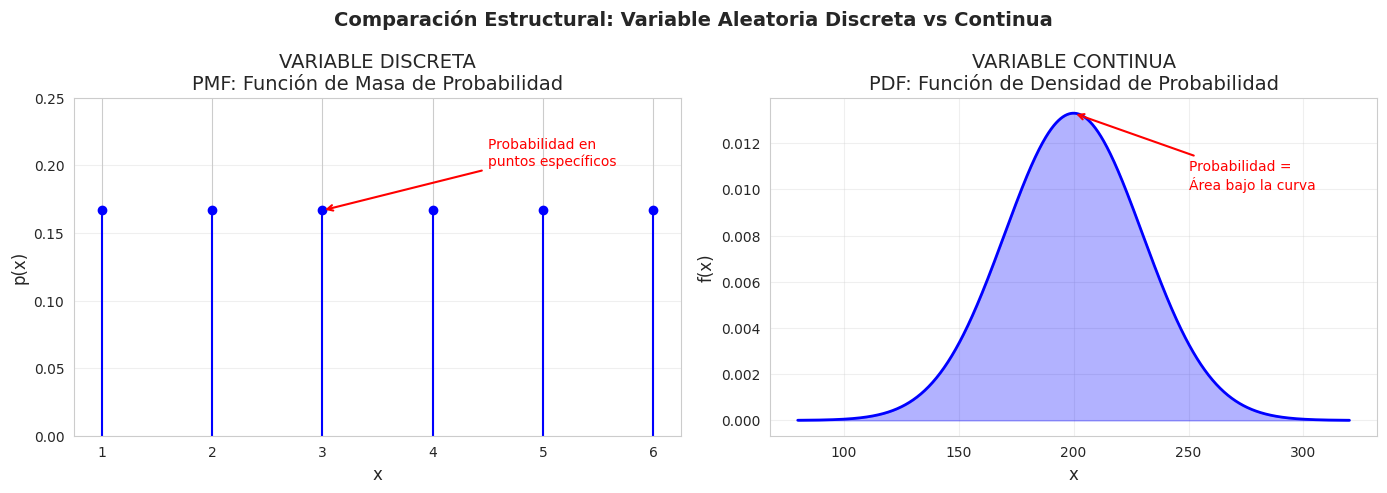

In [10]:
# =====================================================================
# TAREA 4: COMPARACIÓN VISUAL AVANZADA PMF VS PDF WITH ANNOTATIONS
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Variable Discreta ---
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Función de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotación formal para la PMF en un punto exacto
axes[0].annotate('Probabilidad en\npuntos específicos',
                 xy=(3, 1/6),
                 xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5),
                 fontsize=10, color='red')

# --- Gráfico 2: Variable Continua ---
axes[1].plot(x_linea, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x_linea, pdf_normal, alpha=0.3, color='blue')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Función de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotación matemática para la PDF (Área bajo la curva)
axes[1].annotate('Probabilidad =\nÁrea bajo la curva',
                 xy=(200, norm.pdf(200, 200, 30)),
                 xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5),
                 fontsize=10, color='red')

plt.suptitle('Comparación Estructural: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Tarea 5: Aplicación - Muestreo de Variables Aleatorias en el Campus UNL
**Actividad Grupal:** Identificación y clasificación empírica de fenómenos del entorno universitario modelados mediante teoría de distribuciones estadísticas.

In [11]:
# =====================================================================
# TAREA 5: REGISTRO DE VARIABLES ALEATORIAS DEL CAMPUS (PANDAS DATAFRAME)
# =====================================================================

variables_unl = [
    {
        'Área / Ubicación': 'Cafetería Central',
        'Nombre de Variable': 'Tiempo de espera en la fila del bar',
        'Tipo': 'Continua',
        'Valores Posibles (Soporte)': '0 a 15 minutos',
        'Distribución Esperada': 'Exponencial / Normal'
    },
    {
        'Área / Ubicación': 'Biblioteca Central',
        'Nombre de Variable': 'Número de libros solicitados por estudiante al día',
        'Tipo': 'Discreta',
        'Valores Posibles (Soporte)': '{0, 1, 2, 3, 4, ...}',
        'Distribución Esperada': 'Poisson'
    },
    {
        'Área / Ubicación': 'Laboratorios Computación',
        'Nombre de Variable': 'Cantidad de computadoras encendidas concurrentemente',
        'Tipo': 'Discreta',
        'Valores Posibles (Soporte)': '{0, 1, 2, ..., Max_PCs}',
        'Distribución Esperada': 'Binomial'
    },
    {
        'Área / Ubicación': 'Estacionamiento UNL',
        'Nombre de Variable': 'Tiempo de permanencia de un vehículo en el campus',
        'Tipo': 'Continua',
        'Valores Posibles (Soporte)': 't > 0 (horas)',
        'Distribución Esperada': 'Normal / Log-Normal'
    },
    {
        'Área / Ubicación': 'Aulas de Clase',
        'Nombre de Variable': 'Número de estudiantes que llegan tarde a la sesión',
        'Tipo': 'Discreta',
        'Valores Posibles (Soporte)': '{0, 1, 2, 3, ..., N_Alumnos}',
        'Distribución Esperada': 'Binomial o Poisson'
    }
]

# Construcción y visualización limpia de la matriz de registro
df_unl = pd.DataFrame(variables_unl)
print("MATRIZ DE CLASIFICACIÓN DE VARIABLES DEL ENTORNO UNL:")
print("=" * 90)
print(df_unl.to_string(index=False))
print("=" * 90)

MATRIZ DE CLASIFICACIÓN DE VARIABLES DEL ENTORNO UNL:
        Área / Ubicación                                   Nombre de Variable     Tipo   Valores Posibles (Soporte) Distribución Esperada
       Cafetería Central                  Tiempo de espera en la fila del bar Continua               0 a 15 minutos  Exponencial / Normal
      Biblioteca Central   Número de libros solicitados por estudiante al día Discreta         {0, 1, 2, 3, 4, ...}               Poisson
Laboratorios Computación Cantidad de computadoras encendidas concurrentemente Discreta      {0, 1, 2, ..., Max_PCs}              Binomial
     Estacionamiento UNL    Tiempo de permanencia de un vehículo en el campus Continua                t > 0 (horas)   Normal / Log-Normal
          Aulas de Clase   Número de estudiantes que llegan tarde a la sesión Discreta {0, 1, 2, 3, ..., N_Alumnos}    Binomial o Poisson


## Trabajo Autónomo (Post-Laboratorio)
Desarrollo programático de la extensión autónoma para una **Distribución Binomial** ($n=20$, $p=0.40$), evaluando 3 probabilidades analíticas específicas asociadas.

EVALUACIÓN DE DISTRIBUCIÓN BINOMIAL AUTÓNOMA (n=20, p=0.4):
-----------------------------------------------------------------
1. Probabilidad Exacta P(X = 8)     : 0.1797
2. Probabilidad Acumulada P(X <= 5) : 0.1256
3. Probabilidad Extrema P(X > 12)   : 0.0210
-----------------------------------------------------------------


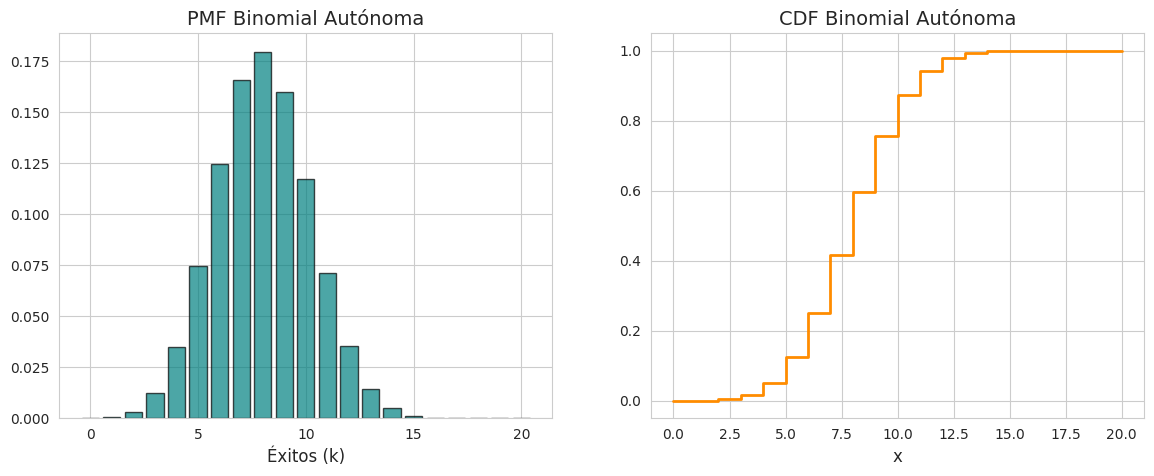

In [12]:
# =====================================================================
# TRABAJO AUTÓNOMO: MODELADO DE DISTRIBUCIÓN BINOMIAL SOBERANA
# =====================================================================

n_autonomo = 20
p_autonomo = 0.40
dist_binom_aut = binom(n_autonomo, p_autonomo)

k_valores = np.arange(0, n_autonomo + 1)
pmf_aut = dist_binom_aut.pmf(k_valores)
cdf_aut = dist_binom_aut.cdf(k_valores)

# Cálculos específicos solicitados:
prob_exacta_8 = dist_binom_aut.pmf(8)                  # 1. P(X = 8)
prob_maximo_5  = dist_binom_aut.cdf(5)                  # 2. P(X <= 5)
prob_mas_de_12 = 1 - dist_binom_aut.cdf(12)             # 3. P(X > 12)

print("EVALUACIÓN DE DISTRIBUCIÓN BINOMIAL AUTÓNOMA (n=20, p=0.4):")
print("-" * 65)
print(f"1. Probabilidad Exacta P(X = 8)     : {prob_exacta_8:.4f}")
print(f"2. Probabilidad Acumulada P(X <= 5) : {prob_maximo_5:.4f}")
print(f"3. Probabilidad Extrema P(X > 12)   : {prob_mas_de_12:.4f}")
print("-" * 65)

# Gráfico de control autónomo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].bar(k_valores, pmf_aut, color='teal', alpha=0.7, edgecolor='black')
ax[0].set_title('PMF Binomial Autónoma')
ax[0].set_xlabel('Éxitos (k)')

ax[1].step(k_valores, cdf_aut, where='post', color='darkorange', linewidth=2)
ax[1].set_title('CDF Binomial Autónoma')
ax[1].set_xlabel('x')
plt.show()

## Preguntas de Control - Desarrollo Teórico-Práctico

1. **¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**
   * **Discreta:** Toma valores pertenecientes a conjuntos finitos o infinitos numerables (se asocia con el proceso de *contar*). Ejemplo: Número de alumnos impuntuales.
   * **Continua:** Se define sobre un rango o intervalo continuo de los números reales (se asocia con el proceso de *medir*). Ejemplo: Tiempo exacto de procesamiento en milisegundos.

2. **¿Por qué en una variable continua $P(X=x)=0$ para cualquier valor específico $x$?**
   Porque la probabilidad en distribuciones continuas corresponde geométricamente al *área bajo la curva* de su PDF. Al evaluar un único punto infinitesimal, el ancho del intervalo es cero, lo que anula la integral ($Area = 0$). Solo posee significado probabilístico el cálculo sobre intervalos coherentes, tales como $P(a \le X \le b)$.

3. **Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?**
   La CDF ($F(x)$) es la función que acumula la masa o densidad de probabilidad desde el extremo izquierdo hasta un umbral $x$.
   * En el caso discreto, se obtiene mediante la suma parcial: $F(x) = \sum_{t \le x} p(t)$.
   * En el caso continuo, se obtiene mediante integración: $F(x) = \int_{-\infty}^{x} f(t)dt$.
   A la inversa, para recuperar la PDF continua a partir de la CDF, se aplica el teorema fundamental del cálculo mediante la derivada: $f(x) = \frac{d}{dx}F(x)$.

VALIDACIÓN DE CASOS DE CONTROL:
-----------------------------------------------------------------
• Evaluación continua: Para f(x)=2x en [0,1], P(X = 5) es idénticamente 0
  debido a la naturaleza del soporte y a que la probabilidad en un punto es cero.
  Resultado formal: P(X = 5) = 0.0
-----------------------------------------------------------------


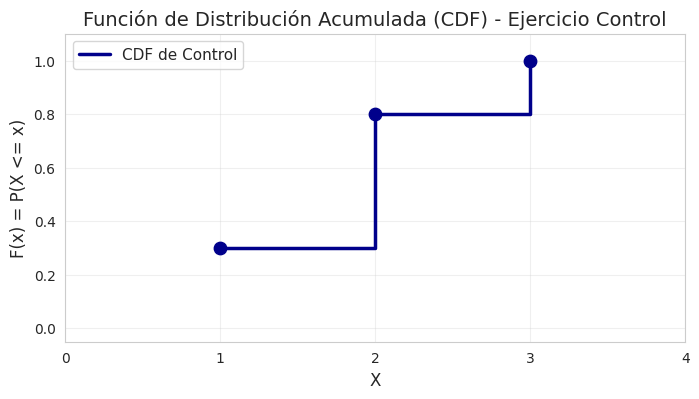

In [13]:
# =====================================================================
# VALIDACIÓN COMPUTACIONAL DE LAS PREGUNTAS DE CONTROL DE LA GUÍA
# =====================================================================

print("VALIDACIÓN DE CASOS DE CONTROL:")
print("-" * 65)

# Caso Continuo: PDF f(x) = 2x en [0,1]. Calcular P(X = 5)
print("• Evaluación continua: Para f(x)=2x en [0,1], P(X = 5) es idénticamente 0")
print("  debido a la naturaleza del soporte y a que la probabilidad en un punto es cero.")
print(f"  Resultado formal: P(X = 5) = 0.0")

print("-" * 65)

# Caso Graficar CDF Discreta de valores {1, 2, 3} con probs {0.3, 0.5, 0.2}
x_ctrl = np.array([1, 2, 3])
pmf_ctrl = np.array([0.3, 0.5, 0.2])
cdf_ctrl = np.cumsum(pmf_ctrl)

plt.figure(figsize=(8, 4))
plt.step(x_ctrl, cdf_ctrl, where='post', color='darkblue', linewidth=2.5, label='CDF de Control')
plt.scatter(x_ctrl, cdf_ctrl, color='darkblue', s=80, zorder=5)
plt.title('Función de Distribución Acumulada (CDF) - Ejercicio Control')
plt.xlabel('X')
plt.ylabel('F(x) = P(X <= x)')
plt.xticks([0, 1, 2, 3, 4])
plt.ylim(-0.05, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()